# QUBO Validation

Build a real optimization instance, inspect candidate decisions, and visualize the QUBO matrix structure.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.benchmarks.benchmark_config import load_scenario_config
from src.network.topology import build_topology
from src.simulation.state_tracker import initialize_state
from src.simulation.event_loop import pre_step_update
from src.optimization.decision_variables import build_optimization_instance
from src.optimization.qubo_builder import build_qubo
from src.utils.seed import seed_everything
from src.workloads.traffic_generator import create_users

sns.set_theme(style='whitegrid', context='talk')

In [2]:
config = load_scenario_config('../configs/base.yaml', '../configs/simulation/wireless_dense.yaml')
rng = seed_everything(config['scenario']['seed'])
topology = build_topology(config, rng)
users = create_users(config, rng, list(topology.base_stations))
tracker = initialize_state(topology)
paths = pre_step_update(config, topology, users, tracker, rng, 0)
instance = build_optimization_instance(config, config['scenario']['name'], 0, users, topology, paths, tracker.edge_queues)
qubo = build_qubo(instance)
qubo.metadata

{'num_variables': 313, 'num_option_variables': 104, 'num_slack_variables': 209}

In [3]:
option_rows = []
for user_id, options in instance.options_by_user.items():
    for option in options[:6]:
        option_rows.append({
            'user_id': user_id,
            'option_id': option.option_id,
            'tier': option.service_tier,
            'edge_id': option.edge_id,
            'latency_ms': option.estimated_latency_ms,
            'goodput_mbps': option.estimated_goodput_mbps,
            'objective_cost': option.objective_cost,
        })
option_df = pd.DataFrame(option_rows)
option_df.head(12)

,user_id,option_id,tier,edge_id,latency_ms,goodput_mbps,objective_cost
0,user0,user0::edge2::bs0->edge2:p0::priority,priority,edge2,15.886682,58.411061,-1.172076
1,user0,user0::edge2::bs0->edge2:p0::nominal,nominal,edge2,15.283603,48.675884,1.584845
2,user0,user0::edge1::bs0->edge1:p0::priority,priority,edge1,18.041528,58.411061,2.247864
3,user0,user0::edge2::bs0->edge2:p1::priority,priority,edge2,18.567747,58.411061,4.284658
4,user0,user0::edge1::bs0->edge1:p0::nominal,nominal,edge1,17.438449,48.675884,4.880201
5,user0,user0::edge2::bs0->edge2:p1::nominal,nominal,edge2,17.964669,48.675884,5.338337
6,user1,user1::edge2::bs0->edge2:p0::priority,priority,edge2,7.611003,4.918587,-6.887864
7,user1,user1::edge1::bs0->edge1:p0::priority,priority,edge1,8.515849,4.918587,-5.528223
8,user1,user1::edge2::bs0->edge2:p0::nominal,nominal,edge2,7.553871,4.098823,-4.396996
9,user1,user1::edge1::bs0->edge1:p1::priority,priority,edge1,9.828149,4.918587,-3.691003


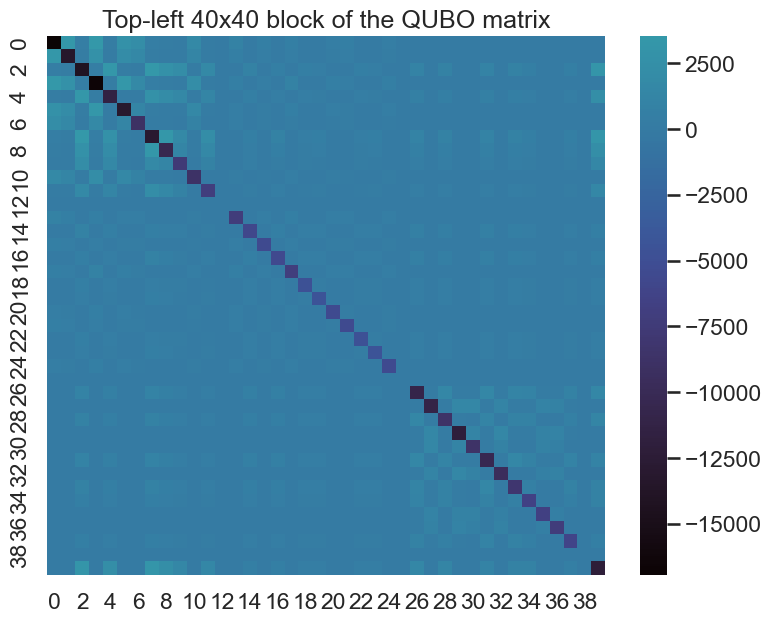

In [4]:
plt.figure(figsize=(9, 7))
sns.heatmap(qubo.matrix[:40, :40], cmap='mako', center=0)
plt.title('Top-left 40x40 block of the QUBO matrix')
plt.show()

In [5]:
constraint_rows = [
    {'constraint': name, 'capacity_units': constraint.capacity_units, 'num_weighted_options': len(constraint.option_weights)}
    for name, constraint in instance.capacities.items()
]
pd.DataFrame(constraint_rows).sort_values('num_weighted_options', ascending=False).head(12)

,constraint,capacity_units,num_weighted_options
4,radio::bs1,20,78
7,slice_radio::bs1::mMTC,7,52
16,edge::edge1,20,48
12,edge::edge0,24,36
19,slice_edge::edge1::mMTC,7,30
0,radio::bs0,20,26
15,slice_edge::edge0::mMTC,8,24
36,path::bs1->edge1:p0,15,18
34,path::bs1->edge0:p1,15,18
33,path::bs1->edge0:p0,10,18
